# 624 Hektor

## Initialize

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from astroquery.jplhorizons import Horizons

In [44]:
DAYS_PER_JULIAN_YEAR = 365.25

OBJECT = {
    'SUN': {
        'id': '10',
        'name': 'Sun',
        'color': 'darkorange'
    },
    'JUPITER': {
        'id': '5',
        'name': 'Jupiter',
        'color': 'chocolate'
    },
    'HEKTOR': {
        'id': 'Hektor',
        'name': '624 Hektor',
        'color': 'lightseagreen'
    }
}

EPOCH_START_JD = 2461143.5

In [27]:
# Load data
col = ['time', 'long', 'x', 'y', 'z']

r_j = pd.read_csv('JUPITER.aei', sep='\s+', skiprows=4, names=col)
r_h = pd.read_csv('HEKTOR.aei', sep='\s+', skiprows=4, names=col)

In [57]:
# Horizons Data
duration_years = 100
stop_jd = EPOCH_START_JD + (duration_years * DAYS_PER_JULIAN_YEAR)

start_iso = Time(EPOCH_START_JD, format='jd').to_value('iso', subfmt='date')
stop_iso = Time(stop_jd, format='jd').to_value('iso', subfmt='date')

epochs = {
    'start': start_iso,
    'stop': stop_iso,
    'step': '500d'
}

obj_h_hor = Horizons(id=OBJECT['HEKTOR']['id'], location='@sun', epochs=epochs)
vec_h_hor = obj_h_hor.vectors()

obj_j_hor = Horizons(id=OBJECT['JUPITER']['id'], location='@sun', epochs=epochs)
vec_j_hor = obj_j_hor.vectors()

/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [29]:
def get_rotation_coords(df_target, df_jupiter):
    theta = np.arctan2(df_jupiter['y'], df_jupiter['x'])
    
    x_rot = df_target['x'] * np.cos(theta) + df_target['y'] * np.sin(theta) - (df_jupiter['x'] * np.cos(theta) + df_jupiter['y'] * np.sin(theta))
    y_rot = -df_target['x'] * np.sin(theta) + df_target['y'] * np.cos(theta) - (-df_jupiter['x'] * np.sin(theta) + df_jupiter['y'] * np.cos(theta))
    z_rot = df_target['z'] - df_jupiter['z']
    
    return x_rot, y_rot, z_rot

## ICRF

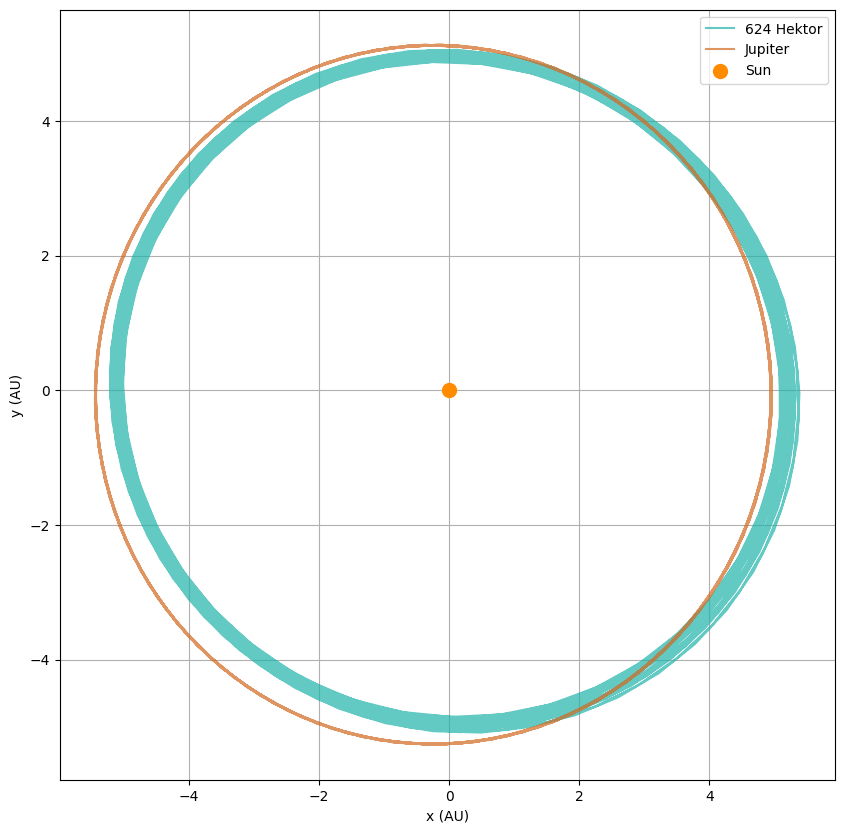

In [45]:
# ICRF Plotting
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(r_h['x'], r_h['y'], label=OBJECT['HEKTOR']['name'], color=OBJECT['HEKTOR']['color'], alpha=0.7, zorder=2)
ax.plot(r_j['x'], r_j['y'], label=OBJECT['JUPITER']['name'], color=OBJECT['JUPITER']['color'], alpha=0.7, zorder=2)
ax.scatter(0, 0, label=OBJECT['SUN']['name'], color=OBJECT['SUN']['color'], s=100, zorder=2)

ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.legend()
ax.grid(True)

#ax.set_xlim(-1.5, 1.5)
#ax.set_ylim(-1.5, 1.5)

plt.show()

## Jupiter-centric Rotational Coordinates

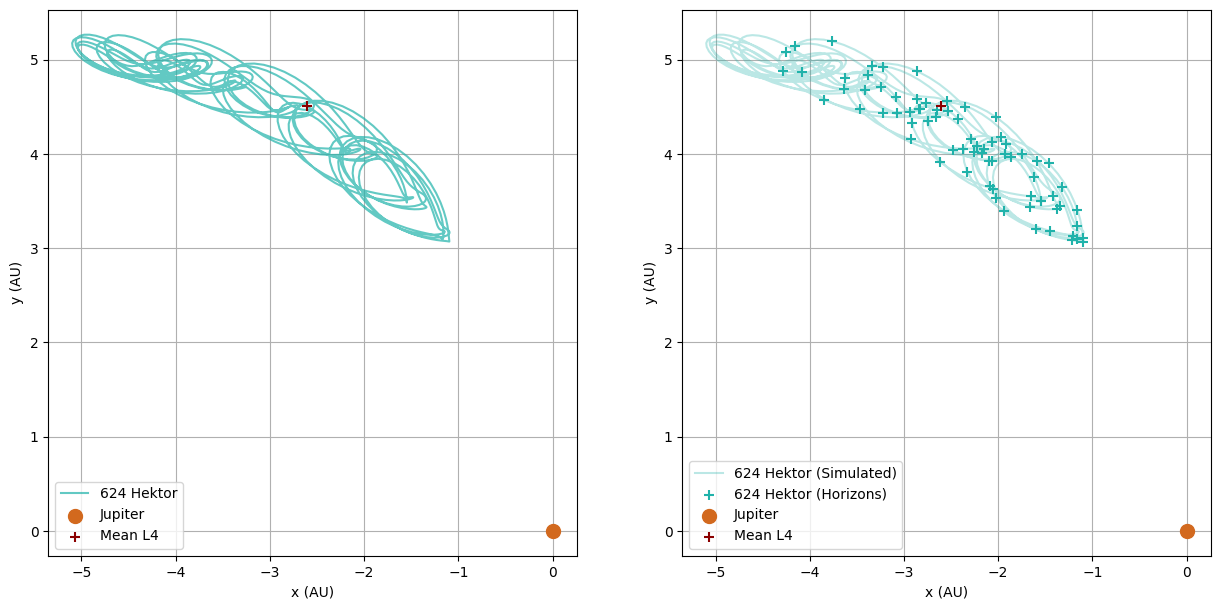

In [62]:
# Rotational Coordinates
x_rot_h, y_rot_h, z_rot_h = get_rotation_coords(r_h, r_j)

# Rotation Coordinates (Horizons)
x_rot_h_hor, y_rot_h_hor, z_rot_h_hor = get_rotation_coords(vec_h_hor, vec_j_hor)

# L4 Point Calculation
r_j_avg = np.sqrt(r_j['x']**2 + r_j['y']**2).mean()
l4_x = -0.5 * r_j_avg
l4_y = (np.sqrt(3) / 2) * r_j_avg 

# Rotational Coordinates Plotting
fig, (ax1, ax2) = plt.subplots(figsize=(15, 15), ncols=2)

ax1.plot(x_rot_h, y_rot_h, label=OBJECT['HEKTOR']['name'], color=OBJECT['HEKTOR']['color'], alpha=0.7, zorder=2)
ax1.scatter(0, 0, label=OBJECT['JUPITER']['name'], color=OBJECT['JUPITER']['color'], s=100, zorder=2)
ax1.scatter(l4_x, l4_y, color='darkred', label='Mean L4', marker='+', s=50, zorder=3)

ax1.set_aspect('equal')
ax1.set_xlabel('x (AU)')
ax1.set_ylabel('y (AU)')
ax1.legend(loc='lower left')
ax1.grid(True)

ax2.plot(x_rot_h, y_rot_h, label=f"{OBJECT['HEKTOR']['name']} (Simulated)", color=OBJECT['HEKTOR']['color'], alpha=0.3, zorder=2)
ax2.scatter(x_rot_h_hor, y_rot_h_hor, label=f"{OBJECT['HEKTOR']['name']} (Horizons)", color=OBJECT['HEKTOR']['color'], marker='+', s=50, zorder=3)
ax2.scatter(0, 0, label=OBJECT['JUPITER']['name'], color=OBJECT['JUPITER']['color'], s=100, zorder=3)
ax2.scatter(l4_x, l4_y, color='darkred', label='Mean L4', marker='+', s=50, zorder=3)

ax2.set_aspect('equal')
ax2.set_xlabel('x (AU)')
ax2.set_ylabel('y (AU)')
ax2.legend(loc='lower left')
ax2.grid(True)

plt.show()